In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../src/")

In [3]:
RANDOM_STATE=42

In [4]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
import shap
from joblib import dump, load
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd

# eXplainable AI

Since in the model selection phase of the previous task, we have identified a RandomForestClassifier (with a specific data preprocessing step) as the best classifier for our goals, let's apply the XAI techniques to it.

## Dataset generation

Let's reconstruct the classifier.

In [5]:
from classification_utility import train_test_for_non_distance, split_in_train_and_validation

In [6]:
train_set, test_set, train_label, test_label=train_test_for_non_distance()

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


In [7]:
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

In [8]:
print(f'TRAINING (Oversampled): {train_set_os.shape[0]} - {train_label_os.shape[0]}')
print(f'TEST (Oversampled): {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING (Oversampled): 672056 - 672056
TEST (Oversampled): 32586 - 32586


In [9]:
TR_set_os, VD_set_os, TR_label_os, VD_label_os=split_in_train_and_validation(train_set_os, train_label_os)
print(f'TRAINING (Oversampled): {TR_set_os.shape[0]} - {TR_label_os.shape[0]}')
print(f'VALIDATION (Oversampled): {VD_set_os.shape[0]} - {VD_label_os.shape[0]}')
print(f'TEST (Oversampled): {test_set.shape[0]} - {test_label.shape[0]}')

TRAINING (Oversampled): 470439 - 470439
VALIDATION (Oversampled): 201617 - 201617
TEST (Oversampled): 32586 - 32586


In [10]:
#Custom function to print the classification report con training/valid
def print_report(train_label, train_predictions, validation_label, valid_predictions, v_or_t='TEST'):
    #v_or_t to print TEST or VALIDATION RESULTS
    classes=['not top20', 'top20']
    if train_label is not None:
        print('TRAINING SET RESULTS')
        print(classification_report(train_label, train_predictions, target_names=classes))
        print('--------------------')
    print(v_or_t+' SET RESULTS')
    print(classification_report(validation_label, valid_predictions, target_names=classes))

In [11]:
rf = RandomForestClassifier(n_estimators=30, 
                             criterion='entropy',
                             max_features='sqrt',
                             max_depth=30, 
                             min_samples_split=25,
                             min_samples_leaf=10,
                             bootstrap=True)
rf = rf.fit(train_set_os, train_label_os)
train_pred_rf = rf.predict(train_set_os)
test_pred_rf = rf.predict(test_set)
print_report(train_label=train_label_os, train_predictions=train_pred_rf, validation_label=test_label, valid_predictions=test_pred_rf)

TRAINING SET RESULTS
              precision    recall  f1-score   support

   not top20       0.92      0.93      0.93    402429
       top20       0.90      0.87      0.89    269627

    accuracy                           0.91    672056
   macro avg       0.91      0.90      0.91    672056
weighted avg       0.91      0.91      0.91    672056

--------------------
TEST SET RESULTS
              precision    recall  f1-score   support

   not top20       0.91      0.92      0.91     28066
       top20       0.45      0.43      0.44      4520

    accuracy                           0.85     32586
   macro avg       0.68      0.67      0.68     32586
weighted avg       0.85      0.85      0.85     32586



In [12]:
# Create the SHAP explainer for the Random Forest model
rf_explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")

We were not able to define a TreeExplainer that performed an 'interventional perturbation' due to computational limitations. We will use only the 'tree_path_dependent' method instead.

In [13]:
# Determine the SHAP values for the test set
# shap_values = rf_explainer.shap_values(test_set)

In [14]:
# shap_values

In [15]:
# Save the SHAP values in a file
# dump(shap_values, "shap_values_distributional.joblib")

In [16]:
# Load the SHAP values from a file
shap_values = load("shap_values_distributional.joblib")

In [17]:
shap_values

array([[[ 0.0429741 , -0.0429741 ],
        [ 0.04785275, -0.04785275],
        [-0.0538742 ,  0.0538742 ],
        ...,
        [-0.02389954,  0.02389954],
        [-0.12365953,  0.12365953],
        [ 0.01558981, -0.01558981]],

       [[-0.02303124,  0.02303124],
        [-0.00204869,  0.00204869],
        [-0.0270597 ,  0.0270597 ],
        ...,
        [ 0.01619873, -0.01619873],
        [-0.07437197,  0.07437197],
        [-0.01384713,  0.01384713]],

       [[-0.01718087,  0.01718087],
        [ 0.01655121, -0.01655121],
        [-0.03020833,  0.03020833],
        ...,
        [ 0.00030146, -0.00030146],
        [-0.01070041,  0.01070041],
        [-0.00828825,  0.00828825]],

       ...,

       [[-0.00966793,  0.00966793],
        [ 0.04130594, -0.04130594],
        [-0.02794902,  0.02794902],
        ...,
        [ 0.01760635, -0.01760635],
        [ 0.04164181, -0.04164181],
        [-0.00664996,  0.00664996]],

       [[ 0.005622  , -0.005622  ],
        [ 0.02066057, -0.02

'shap_values' contains the SHAP values for every feature for each instance in your test set, so we can break down the contribution of every feature to every individual prediction.

## Global interpretability

In [18]:
shap_values_class_1 = shap_values[:, :, 1]  # SHAP contributions for the class '1'
print(shap_values_class_1.shape)
shap_values_class_0 = shap_values[:, :, 0]  # SHAP contributions for the class '0'
print(shap_values_class_0.shape)

(32586, 12)
(32586, 12)


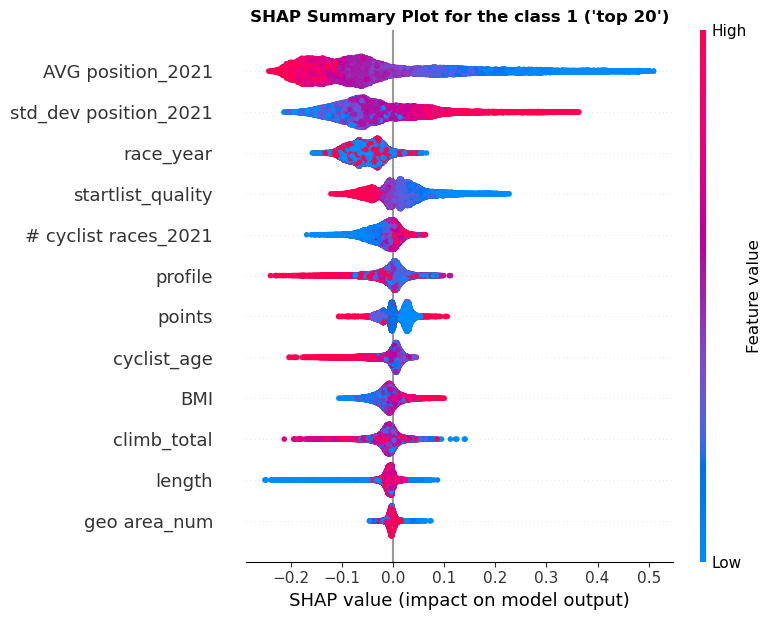

In [19]:
plt.title("SHAP Summary Plot for the class 1 ('top 20')", fontweight='bold')
shap.summary_plot(shap_values_class_1, test_set)
plt.show()
plt.close()

**SHAP Summary plot observations**
- From the SHAP summary plot we can see that the features that contribute most to the final prediction are the statistics for the races up to 2021, in particular the most influential feature is _'AVG position_2021'_. In fact, the plot shows that the instances with a very low value of AVG position have a high probability of being classified as _'top 20'_ (class 1). This is clearly an observation that makes sense, as we would expect valuable cyclists to have a low AVG position value.
- The second most impactful feature is  _'std_dev_position_2021'_ but here we have an opposite situation; for those cyclists having a lower standard deviations on their placements, there is an higher probability to be classified as _'not top 20'_ (class 0). Actually this pattern seems non sensical since we expect valuable cyclists not to have a strong variations on their placements. But on the other hand we have also to remember that most of the cyclists have performed very few races, in particular a consistent number of cyclists has only one recorded placement hence with a 0 value of std_dev.
- As for the startlist_quality feature, the lower the value, the more likely the cyclists are to be classified as top_20. This could be a reasonable result as we expect races with high values of startlist quality to attract many cyclists, thus reducing our probability of being in the top 20.

In general these 3 features are the most impactful for the model to classify the istances as 'top_20'. For the other features we notice that there is not a general trend but there are differences depending on the single instances. The 'geo area' feature is the least influent in the class assignment.

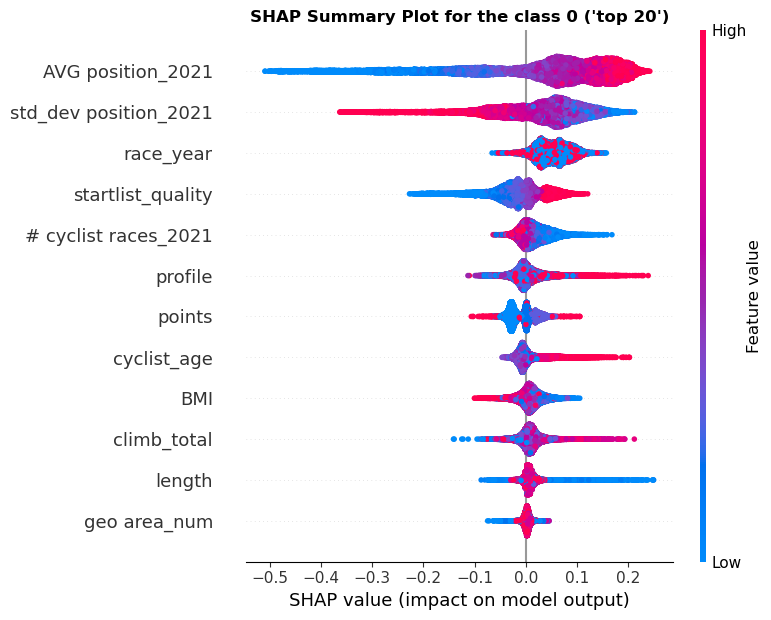

In [20]:
plt.title("SHAP Summary Plot for the class 0 ('top 20')", fontweight='bold')
shap.summary_plot(shap_values_class_0, test_set)
plt.show()
plt.close()

In [21]:
print(test_set.columns.tolist())

['cyclist_age', 'race_year', 'points', 'length', 'climb_total', 'profile', 'startlist_quality', 'BMI', 'AVG position_2021', '# cyclist races_2021', 'std_dev position_2021', 'geo area_num']


In [22]:
# Convert shap_values to shap.Explanation object
shap_values_exp = shap.Explanation(values=shap_values[:, :, 1], base_values=None, data=test_set.values, feature_names=test_set.columns)

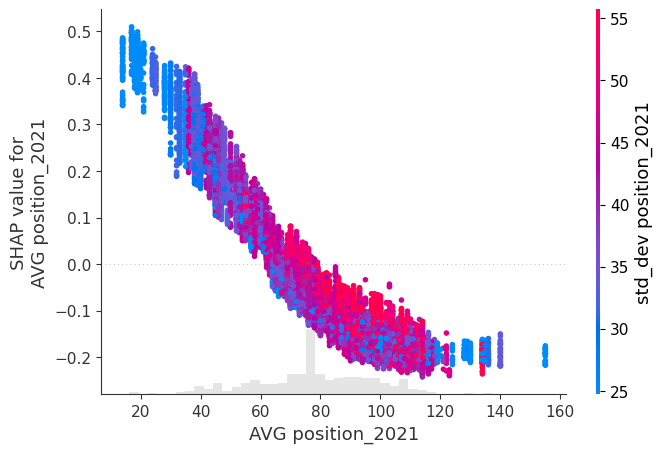

In [23]:
# Plot the scatter plot of the SHAP values for the feature 'AVG position_2021' and the feature 'std_dev position_2021'
shap.plots.scatter(shap_values_exp[:, "AVG position_2021"], color=shap_values_exp[:, "std_dev position_2021"])

- This scatterplot shows that cyclists with a very low AVG position have also a low standard deviation with a very high SHAP value for the 1 class. Also those cyclists with very high AVG position have a low standard deviation but, in this situation, there is a contribution toward the 0 class. 
- Actually those cyclists with a high standard deviation of the positions are those with an AVG position in the central part of the distribution; in this situation the standard deviation may influence the final classification, in particular high variability in the results may controbute to be classified to the 0 class.
- We can observe that for low values of the avg position there is a more evident vertical dispersion of points suggesting that, in this case, the final prevision is more dependend also on the other features.

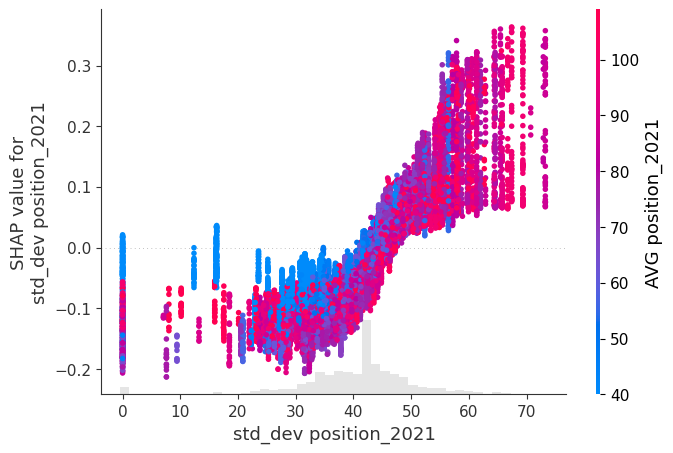

In [24]:
# Plot the scatter plot of the SHAP values for the feature 'AVG position_2021' and the feature 'std_dev position_2021'
shap.plots.scatter(shap_values_exp[:, "std_dev position_2021"], color=shap_values_exp[:, "AVG position_2021"])

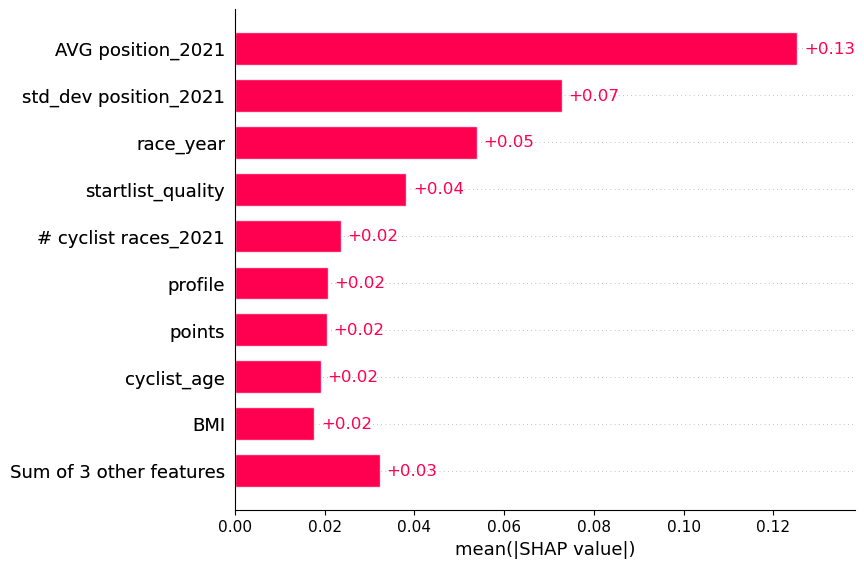

In [25]:
# Plot the bar plot of the SHAP values (Absolute values)
shap.plots.bar(shap_values_exp)

Also this visualization confirms that the feature that contributes the most to the prediction is the 'AVG position_2021' feature.

In [26]:
distributional_explanations=pd.DataFrame(shap_values_exp.values, columns=test_set.columns.tolist())
distributional_explanations

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
0,-0.042974,-0.047853,0.053874,0.010602,-0.006988,0.024562,0.057127,-0.005038,0.131346,0.023900,0.123660,-0.015590
1,0.023031,0.002049,0.027060,0.016262,-0.006055,0.017296,0.076689,0.010607,-0.123723,-0.016199,0.074372,0.013847
2,0.017181,-0.016551,0.030208,-0.008231,0.014129,0.002809,0.066707,-0.000191,0.284357,-0.000301,0.010700,0.008288
3,0.019777,0.018115,0.006663,0.002479,-0.005251,0.004989,0.058143,0.016688,0.438739,-0.016684,-0.032469,0.010119
4,0.001408,-0.012432,-0.018025,-0.002970,-0.029506,0.010999,0.052971,-0.009547,-0.179718,-0.080433,0.038486,-0.005393
...,...,...,...,...,...,...,...,...,...,...,...,...
32581,-0.007978,-0.035062,0.002536,-0.009815,0.000315,0.010749,-0.024423,-0.013510,-0.089604,-0.006136,-0.067734,-0.003885
32582,-0.007092,-0.047791,0.003528,-0.005669,0.005082,0.005035,-0.021317,-0.024759,-0.091937,0.002643,-0.053314,-0.001185
32583,0.009668,-0.041306,0.027949,-0.015735,0.035284,0.003592,0.006529,-0.018433,0.118395,-0.017606,-0.041642,0.006650
32584,-0.005622,-0.020661,0.006400,0.006630,-0.028284,0.001530,-0.004776,-0.008894,-0.012758,-0.062457,-0.088762,-0.003207


Text(0, 0.5, '')

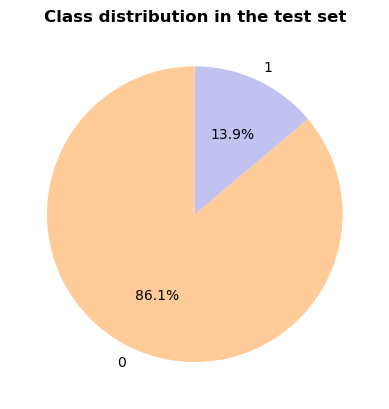

In [30]:
test_label.value_counts().plot.pie(autopct='%1.1f%%', labels=['0', '1'], colors=["#ffcc99", "#c2c2f0"], startangle=90)
plt.title("Class distribution in the test set", fontweight='bold')
plt.ylabel('')

In [31]:
distributional_explanations.describe().drop("count", axis="rows")

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_num
mean,-0.008128,-0.053219,0.007508,-0.007954,-0.009874,-0.005716,0.013909,-0.009306,-0.036149,-0.018008,-0.028215,-0.002260
std,0.029591,0.030077,0.023075,0.015994,0.022008,0.030497,0.049197,0.021384,0.145801,0.026043,0.084448,0.006678
min,-0.202636,-0.157534,-0.106029,-0.250071,-0.212282,-0.239376,-0.121174,-0.105650,-0.242598,-0.168554,-0.212884,-0.045786
25%,-0.013846,-0.075518,-0.008321,-0.011804,-0.018215,-0.017298,-0.014109,-0.020784,-0.141914,-0.034330,-0.084064,-0.005491
50%,0.002537,-0.052332,0.006636,-0.006583,-0.008497,-0.000066,0.013137,-0.008893,-0.073689,-0.013352,-0.045921,-0.002479
75%,0.009126,-0.030225,0.027626,-0.002501,0.000250,0.010423,0.038142,0.001599,0.019321,0.000993,0.018277,0.000842
max,0.045999,0.065771,0.106410,0.087106,0.141170,0.112940,0.227183,0.100285,0.509609,0.063781,0.363474,0.074460


We notice that almost all the features have a negative mean contribution, caused by the fact that most of the test data are classified as 0.
The features _'AVG position_2021'_ and _'std_dev position_2021'_ are those with the highest maximum value, which means that for some instances those features had an important impact on the final class '1' prediction (0.5 and 0.3 respectively). 

## Local interpretability